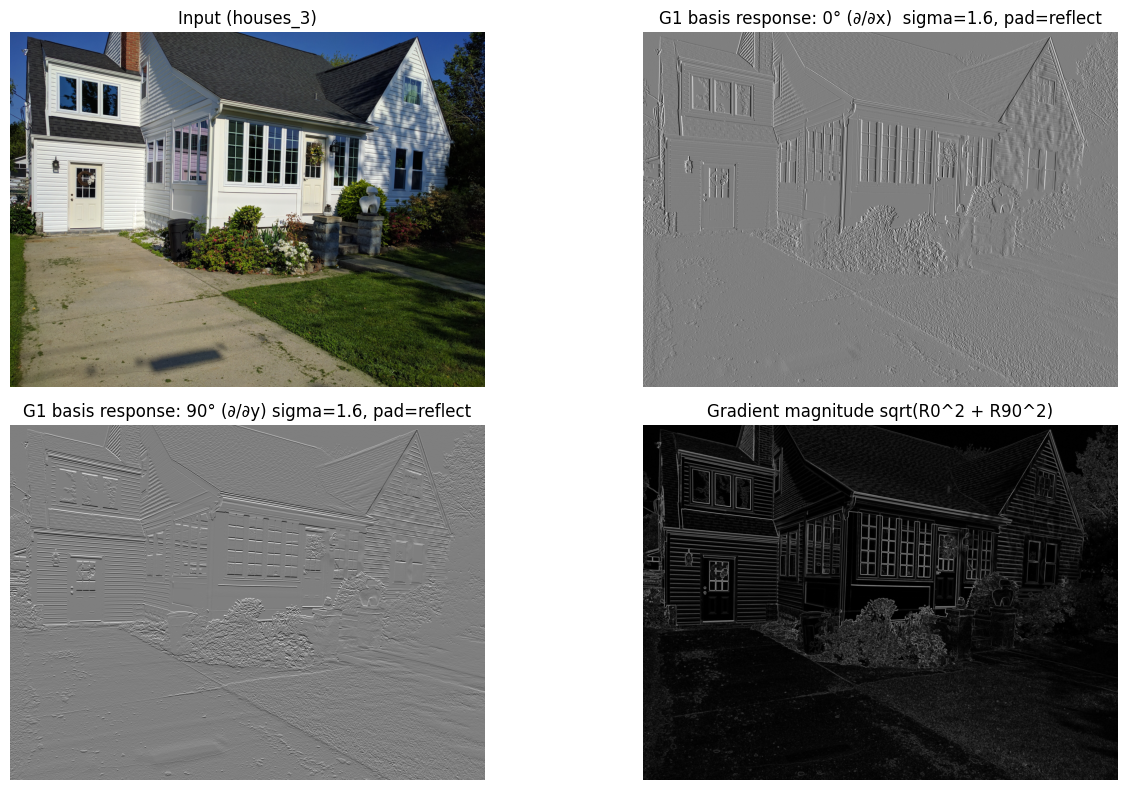

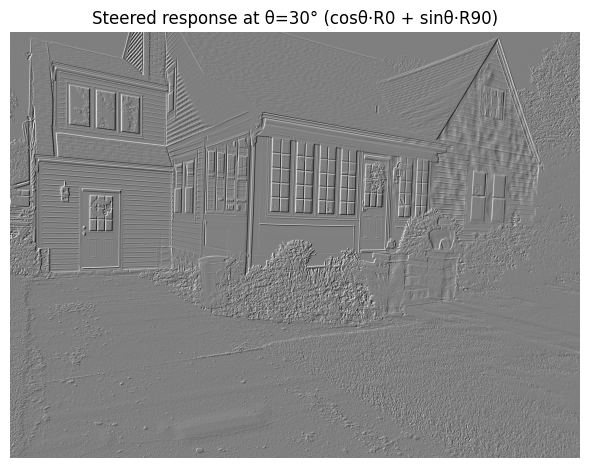

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Helpers: padding mode mapping (from Ex 3.9)
# ----------------------------
BORDER_MAP = {
    "constant": cv2.BORDER_CONSTANT,      # constant value outside
    "clamp": cv2.BORDER_REPLICATE,        # replication / clamping
    "wrap": cv2.BORDER_WRAP,              # wrap-around
    "reflect": cv2.BORDER_REFLECT,        # reflect (…fedc|abcd|dcba…)
    "symmetric": cv2.BORDER_REFLECT_101,  # symmetric-ish (…cdef|abcd|cbad…)
}

def gaussian_1d_and_derivative(sigma: float, radius: int | None = None):
    """
    Builds 1D Gaussian g and its 1D derivative dg sampled on integer grid.
    - g sums to 1
    - dg sums to ~0 (we force zero-mean for numerical stability)
    """
    if radius is None:
        radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=np.float32)

    g = np.exp(-(x * x) / (2 * sigma * sigma))
    g /= (g.sum() + 1e-12)

    # derivative of gaussian (up to a constant scale)
    dg = -(x / (sigma * sigma)) * g

    # enforce exact zero-sum in discrete form (helps avoid bias)
    dg -= dg.mean()

    return g.astype(np.float32), dg.astype(np.float32)

def to_luminance(rgb_u8: np.ndarray) -> np.ndarray:
    """
    Convert RGB uint8 -> float32 luminance in [0,1]
    (Rec.709 weights; common in CV)
    """
    rgb = rgb_u8.astype(np.float32) / 255.0
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    Y = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return Y.astype(np.float32)

def steerable_G1_basis_responses(
    img_u8: np.ndarray,
    sigma: float = 1.5,
    padding: str = "reflect",
    constant_value: float = 0.0,
):
    """
    Returns the 2 "bands":
      R0  = response to G1 at 0 degrees  (x-derivative of Gaussian)
      R90 = response to G1 at 90 degrees (y-derivative of Gaussian)

    Works for grayscale or color input.
    For color, we filter luminance (common for edge-like filtering).
    """
    if padding not in BORDER_MAP:
        raise ValueError(f"padding must be one of {list(BORDER_MAP.keys())}")

    borderType = BORDER_MAP[padding]
    g, dg = gaussian_1d_and_derivative(sigma)

    # if color image, compute luminance; if grayscale, just normalize
    if img_u8.ndim == 3:
        I = to_luminance(img_u8)
    else:
        I = img_u8.astype(np.float32) / 255.0

    # OpenCV sepFilter2D does separable convolution:
    #   out = (kernelX convolve in x) then (kernelY convolve in y)
    # For x-derivative: dg in x, g in y
    R0 = cv2.sepFilter2D(
        I, ddepth=cv2.CV_32F,
        kernelX=dg, kernelY=g,
        borderType=borderType
    )

    # For y-derivative: g in x, dg in y
    R90 = cv2.sepFilter2D(
        I, ddepth=cv2.CV_32F,
        kernelX=g, kernelY=dg,
        borderType=borderType
    )

    # If using BORDER_CONSTANT, OpenCV uses 0 by default; to support other constants:
    # easiest is to pad manually, but most of the time constant=0 is fine.
    # (Keeping this simple & fast.)

    return R0, R90

def visualize_signed_response(resp: np.ndarray, title: str, vmax=None):
    """
    Shows a signed filter response: negative=dark, positive=bright.
    """
    if vmax is None:
        vmax = np.percentile(np.abs(resp), 99) + 1e-12
    plt.imshow(resp, cmap="gray", vmin=-vmax, vmax=vmax)
    plt.title(title)
    plt.axis("off")

# ----------------------------
# Demo on your houses_3.jpg
# ----------------------------
img_path = os.path.join("..", "Files", "Random_Images", "houses_3.jpg")
bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
if bgr is None:
    raise FileNotFoundError(f"Could not read {img_path}")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

sigma = 1.6
padding = "reflect"   # try: "clamp", "wrap", "reflect", "symmetric", "constant"

R0, R90 = steerable_G1_basis_responses(rgb, sigma=sigma, padding=padding)

# Optional: magnitude (looks like edge strength)
mag = np.sqrt(R0*R0 + R90*R90)

plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.imshow(rgb)
plt.title("Input (houses_3)")
plt.axis("off")

plt.subplot(2, 2, 2)
visualize_signed_response(R0, f"G1 basis response: 0° (∂/∂x)  sigma={sigma}, pad={padding}")

plt.subplot(2, 2, 3)
visualize_signed_response(R90, f"G1 basis response: 90° (∂/∂y) sigma={sigma}, pad={padding}")

plt.subplot(2, 2, 4)
plt.imshow(mag, cmap="gray")
plt.title("Gradient magnitude sqrt(R0^2 + R90^2)")
plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------
# (Optional) Demonstrate steering to any angle theta using the paper’s formula:
# R_theta = cos(theta) * R0 + sin(theta) * R90
# ----------------------------
theta_deg = 30
theta = np.deg2rad(theta_deg)
Rtheta = np.cos(theta) * R0 + np.sin(theta) * R90

plt.figure(figsize=(6,5))
visualize_signed_response(Rtheta, f"Steered response at θ={theta_deg}° (cosθ·R0 + sinθ·R90)")
plt.tight_layout()
plt.show()


Saved GIFs:
 - c:\Users\knut1\Documents\Computer_Vision_Exercises\Chapter_3_Image_Processing\outputs_ex3_16\houses_resample_compare.gif
 - c:\Users\knut1\Documents\Computer_Vision_Exercises\Chapter_3_Image_Processing\outputs_ex3_16\chirp_resample_compare.gif


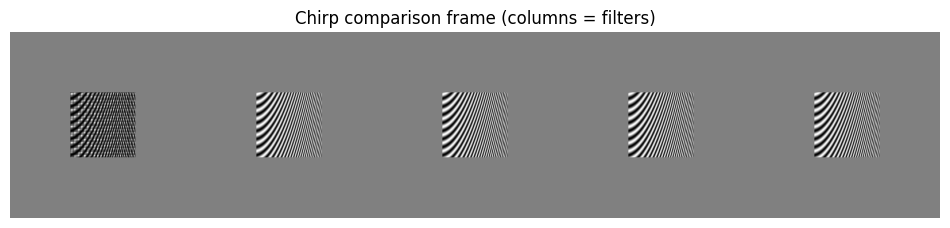